# DEEP LEARNING FINAL PROJECT


# Cell 1 — Mount Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Cell 2 — Dataset path

In [2]:
dataset_path = '/content/drive/MyDrive/DEEPLRL_Data'

# Cell 3 — Imports


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cell 4


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Cell 5


In [5]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=16,        # smaller batch = better gradient estimates on small data
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"Training samples  : {train_data.samples}")
print(f"Validation samples: {validation_data.samples}")
print(f"Class indices     : {train_data.class_indices}")

Found 600 images belonging to 5 classes.
Found 150 images belonging to 5 classes.
Training samples  : 600
Validation samples: 150
Class indices     : {'hdmi': 0, 'rj45': 1, 'sata': 2, 'usba': 3, 'vga': 4}


# Cell 6


In [7]:
labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


# Cell 7


In [8]:
from tensorflow.keras.layers import SeparableConv2D

inputs = tf.keras.Input(shape=(128, 128, 3))

# Block 1 — basic edge detection
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)  # double conv
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.1)(x)

# Block 2 — mid-level features
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)  # double conv
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.1)(x)

# Block 3 — high-level connector shape features
x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

# Block 4 — fine-grained discrimination between similar connectors
x = SeparableConv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)

# Classifier head
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 32, 32, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 16, 16, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 228,453 (892.39 KB)

 Trainable params: 227,045 (886.89 KB)

 Non-trainable params: 1,408 (5.50 KB)

# Cell 8

In [9]:
optimizer = Adam(
    learning_rate=5e-4,   # sweet spot for this dataset size
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Cell 9

In [10]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        min_delta=0.001,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        min_delta=0.001,
        cooldown=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Cell 10

In [11]:
history = model.fit(
    train_data,
    epochs=60,
    validation_data=validation_data,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3473 - loss: 1.5234
Epoch 1: val_loss improved from None to 1.65479, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 363s 9s/step - accuracy: 0.4817 - loss: 1.3362 - val_accuracy: 0.2000 - val_loss: 1.6548 - learning_rate: 5.0000e-04
Epoch 2/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6118 - loss: 1.0185
Epoch 2: val_loss did not improve from 1.65479
38/38 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.6700 - loss: 0.9186 - val_accuracy: 0.2000 - val_loss: 1.6735 - learning_rate: 5.0000e-04
Epoch 3/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8004 - loss: 0.6588
Epoch 3: val_loss did not improve from 1.65479
38/38 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.7883 - loss: 0.6687 - val_accuracy: 0.2000 - val_loss: 1.7325 - learning_rate: 5.0000e-04
Epoch 4/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7895 - loss: 0.6265
Epoch 4:

# Cell 11


In [12]:
loss, accuracy = model.evaluate(validation_data)
print(f'\nValidation Accuracy: {accuracy:.4f}')
print(f'Validation Loss    : {loss:.4f}')

validation_data.reset()
y_pred_probs = model.predict(validation_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_data.classes
class_labels = list(train_data.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2000 - loss: 1.6548

Validation Accuracy: 0.2000
Validation Loss    : 1.6548
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step

Classification Report:
              precision    recall  f1-score   support

        hdmi       0.00      0.00      0.00        30
        rj45       0.20      1.00      0.33        30
        sata       0.00      0.00      0.00        30
        usba       0.00      0.00      0.00        30
         vga       0.00      0.00      0.00        30

    accuracy                           0.20       150
   macro avg       0.04      0.20      0.07       150
weighted avg       0.04      0.20      0.07       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Cell 13 — Plot accuracy

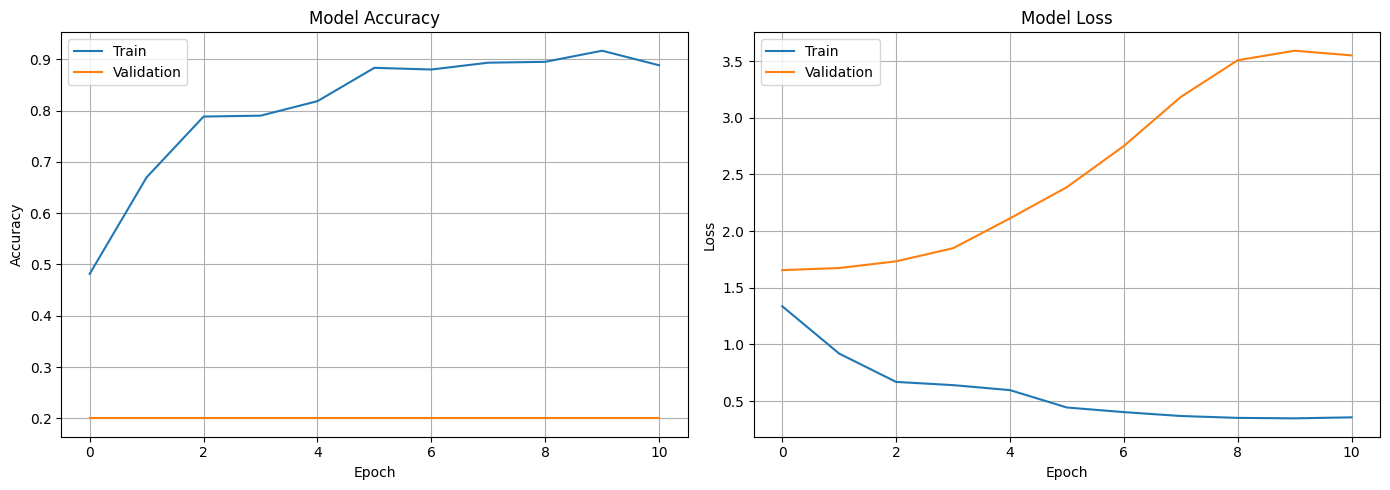

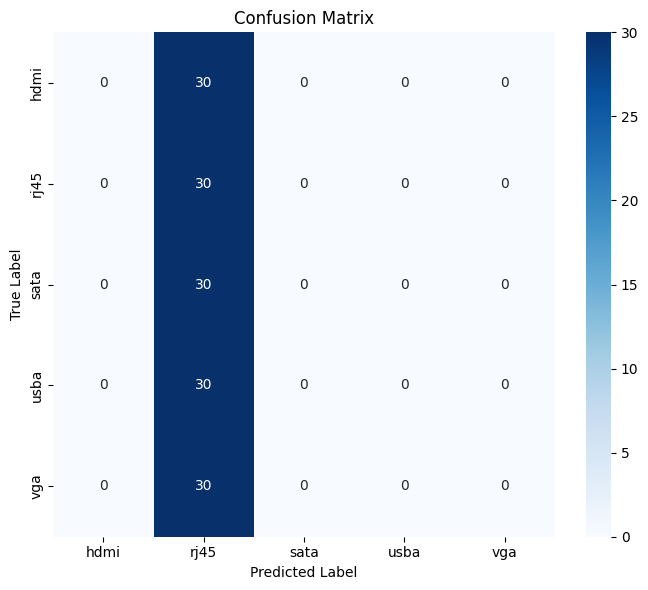

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Cell 14 — Save model

In [14]:
#model.save("cnn_classifier.h5")

# Cell 15 — Download mode

In [15]:
#from google.colab import files
#files.download("cnn_classifier.h5")

# Cell 16 — Test single image in Colab

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {class_labels[predicted_class]} ({confidence:.1f}%)")
plt.show()

In [ ]:


# Upload image from local computer
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Load and resize image
img = image.load_img(filename, target_size=(128,128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Expand dimensions to match model input
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

# Get predicted class index
predicted_class = np.argmax(prediction)

# Get class label names
class_labels = list(train_data.class_indices.keys())



In [ ]:
# Display image
plt.imshow(img)
plt.axis('off')
plt.title("Predicted Class: " + class_labels[predicted_class])
plt.show()

# Streamlit Save

In [ ]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# ── Page config ──────────────────────────────────────────────
st.set_page_config(
    page_title="Connector Classifier",
    page_icon="🔌",
    layout="centered"
)

st.title("🔌 Network Connector Classifier")
st.write("Upload an image to identify the connector type: **SATA, VGA, USB-A, HDMI, or RJ45**")

# ── Load model (cached so it only loads once) ────────────────
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("cnn_classifier.keras")

model = load_model()

CLASS_LABELS = ['hdmi', 'rj45', 'sata', 'usba', 'vga']  # alphabetical — matches flow_from_directory

# ── Upload ───────────────────────────────────────────────────
uploaded_file = st.file_uploader(
    "Choose an image", type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded image", use_column_width=True)

    # Preprocess
    img_resized = img.resize((128, 128))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    with st.spinner("Classifying..."):
        prediction = model.predict(img_array)[0]

    predicted_idx = np.argmax(prediction)
    predicted_label = CLASS_LABELS[predicted_idx]
    confidence = prediction[predicted_idx] * 100

    # ── Results ──────────────────────────────────────────────
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        st.metric("Predicted Connector", predicted_label.upper())
    with col2:
        st.metric("Confidence", f"{confidence:.1f}%")

    # Confidence bar chart for all classes
    st.markdown("#### Confidence per class")
    for label, score in zip(CLASS_LABELS, prediction):
        st.progress(
            float(score),
            text=f"{label.upper()}: {score*100:.1f}%"
        )

    if confidence < 60:
        st.warning(
            "⚠️ Low confidence — the model is unsure. "
            "This may be due to limited training data (especially HDMI)."
        )